In [ ]:
# Standard libraries used throughout the notebook
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns
import itertools
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import math

# --------------------------------------------------------------------------
# PARAMETER — PATH_DATASET
# --------------------------------------------------------------------------

PATH_RAW_DATASET = r"C:\Users\marco\Desktop\Tesi\.LabWork\Data\Data from Suzanne\fitness_calc_PB_H3B.xlsx"
PATH_LOG_READS_NORMALIZED = r"C:/Users/marco/Desktop/Tesi/.LabWork/Results/log_reads_norm.csv"
PATH_LFC = "C:/Users/marco/Desktop/Tesi/.LabWork/Results/lfc_results.csv"
# We load the raw file with no changes.
# data_raw will never be modified — it stays as the original reference.
data_raw = pd.read_excel(PATH_RAW_DATASET)
data_reads_norm = pd.read_csv(PATH_LOG_READS_NORMALIZED)
data_lfc = pd.read_csv(PATH_LFC)

data_reads_norm.columns = data_reads_norm.columns.str.replace(
    "output_", "norm_reads_", regex=False
)

data_lfc.drop(columns=["DECOY", "PYT", "ANCHOR"], inplace=True)

# --------------------------------------------------------------------------
# Data Merging ( unify the datasets)
# --------------------------------------------------------------------------
df_CLR_norm = pd.merge(data_reads_norm, data_lfc, on="seq_id")
df_CLR_norm['seq_id'] = df_CLR_norm['seq_id'].astype(int)
data = pd.merge(data_raw, df_CLR_norm, on="seq_id")
# --------------------------------------------------------------------------
# Data Filtering
# --------------------------------------------------------------------------

MIN_READS_THRESHOLD = 50

n_total   = len(data_raw)
mask_ok   = data["Input_counts"] >= MIN_READS_THRESHOLD
n_removed = (~mask_ok).sum()
n_kept    = mask_ok.sum()

data_filtered = data[mask_ok].copy().reset_index(drop=True)
data_filtered['ANCHOR'] = data_filtered['ANCHOR'].astype(str)

# --------------------------------------------------------------------------
# CONSTANT definition
# --------------------------------------------------------------------------
DRUG_CONCENTRATIONS_raw = [1e-11, 1e-10, 2e-10, 4e-10, 1e-09]
def scale_drug_concentration(drug_linear, 
                             min_real=1e-11, 
                             max_real=1e-9, 
                             min_scaled=0., 
                             max_scaled=100.0):
    """
    Scala la concentrazione lineare del farmaco in un range lineare personalizzato (es. 1-100)
    passando prima per lo spazio logaritmico, per preservare la sensibilità alle basse dosi.
    """
    # 1. Passaggio allo spazio logaritmico (esponenti)
    log_drug = np.log10(drug_linear)
    log_min = np.log10(min_real)  # -11
    log_max = np.log10(max_real)  # -9
    
    # 2. Traslazione e riscalamento lineare dell'esponente nel nuovo range [min_scaled, max_scaled]
    drug_scaled = min_scaled + (log_drug - log_min) * (max_scaled - min_scaled) / (log_max - log_min)
    
    return drug_scaled

DRUG_CONCENTRATIONS = scale_drug_concentration(DRUG_CONCENTRATIONS_raw)


variables = ['ANCHOR', 'DECOY', 'PYT']
lfc = [col for col in data_filtered.columns if 'lfc' in col]
normalized = [col for col in data_filtered.columns if 'norm_reads' in col]

focus_cols = ['seq_id', *variables, *lfc, *normalized]
df_lfc = data_filtered.loc[:, focus_cols]




unique_values = [df_lfc[col].dropna().unique() for col in variables]
combinations_names = list(itertools.product(*unique_values))

stratified_data =  {}
for key_classes, subset in df_lfc.groupby(variables):
    stratified_data[key_classes] = subset.drop(
        columns = variables
    )

## Low reads count filtering -- QC step


  Threshold : Input_counts >= 50
  Total sequences   :    103,239
  Removed sequences :      3,795  (3.68%)
  Kept sequences    :     99,444  (96.32%)


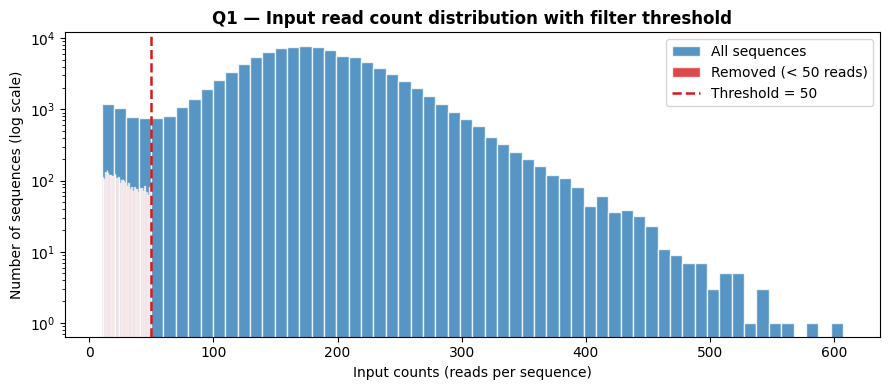

In [9]:

# --------------------------------------------------------------------------
# PARAMETER — MIN_READS_THRESHOLD: minimum number of input reads required
# for a sequence to be kept in the analysis.
#
# Why 50? With 50 reads, the Poisson relative error is 1/sqrt(50) ~ 14%.
# This is the maximum measurement error we accept.

# --------------------------------------------------------------------------
MIN_READS_THRESHOLD = 50

n_total   = len(data_raw)
mask_ok   = data_raw["Input_counts"] >= MIN_READS_THRESHOLD
n_removed = (~mask_ok).sum()
n_kept    = mask_ok.sum()

print(f"\n  Threshold : Input_counts >= {MIN_READS_THRESHOLD}")
print(f"  Total sequences   : {n_total:>10,}")
print(f"  Removed sequences : {n_removed:>10,}  ({n_removed/n_total*100:.2f}%)")
print(f"  Kept sequences    : {n_kept:>10,}  ({n_kept/n_total*100:.2f}%)")

# Build the filtered dataset — this is the starting point for all checks below
data_filtered = data_raw[mask_ok].copy().reset_index(drop=True)

# Plot: show which sequences are removed
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(data_raw["Input_counts"], bins=60, color="#2C7BB6",
        edgecolor="white", alpha=0.8, label="All sequences")
ax.hist(data_raw.loc[~mask_ok, "Input_counts"], bins=60, color="#D7191C",
        edgecolor="white", alpha=0.8, label=f"Removed (< {MIN_READS_THRESHOLD} reads)")
ax.axvline(MIN_READS_THRESHOLD, color="#D7191C", linewidth=1.8,
           linestyle="--", label=f"Threshold = {MIN_READS_THRESHOLD}")

ax.set_yscale("log")
ax.set_title("Q1 — Input read count distribution with filter threshold", fontweight="bold")
ax.set_xlabel("Input counts (reads per sequence)")
ax.set_ylabel("Number of sequences (log scale)")
ax.legend()
plt.tight_layout()
plt.show()


## Input and Output reads distribuction

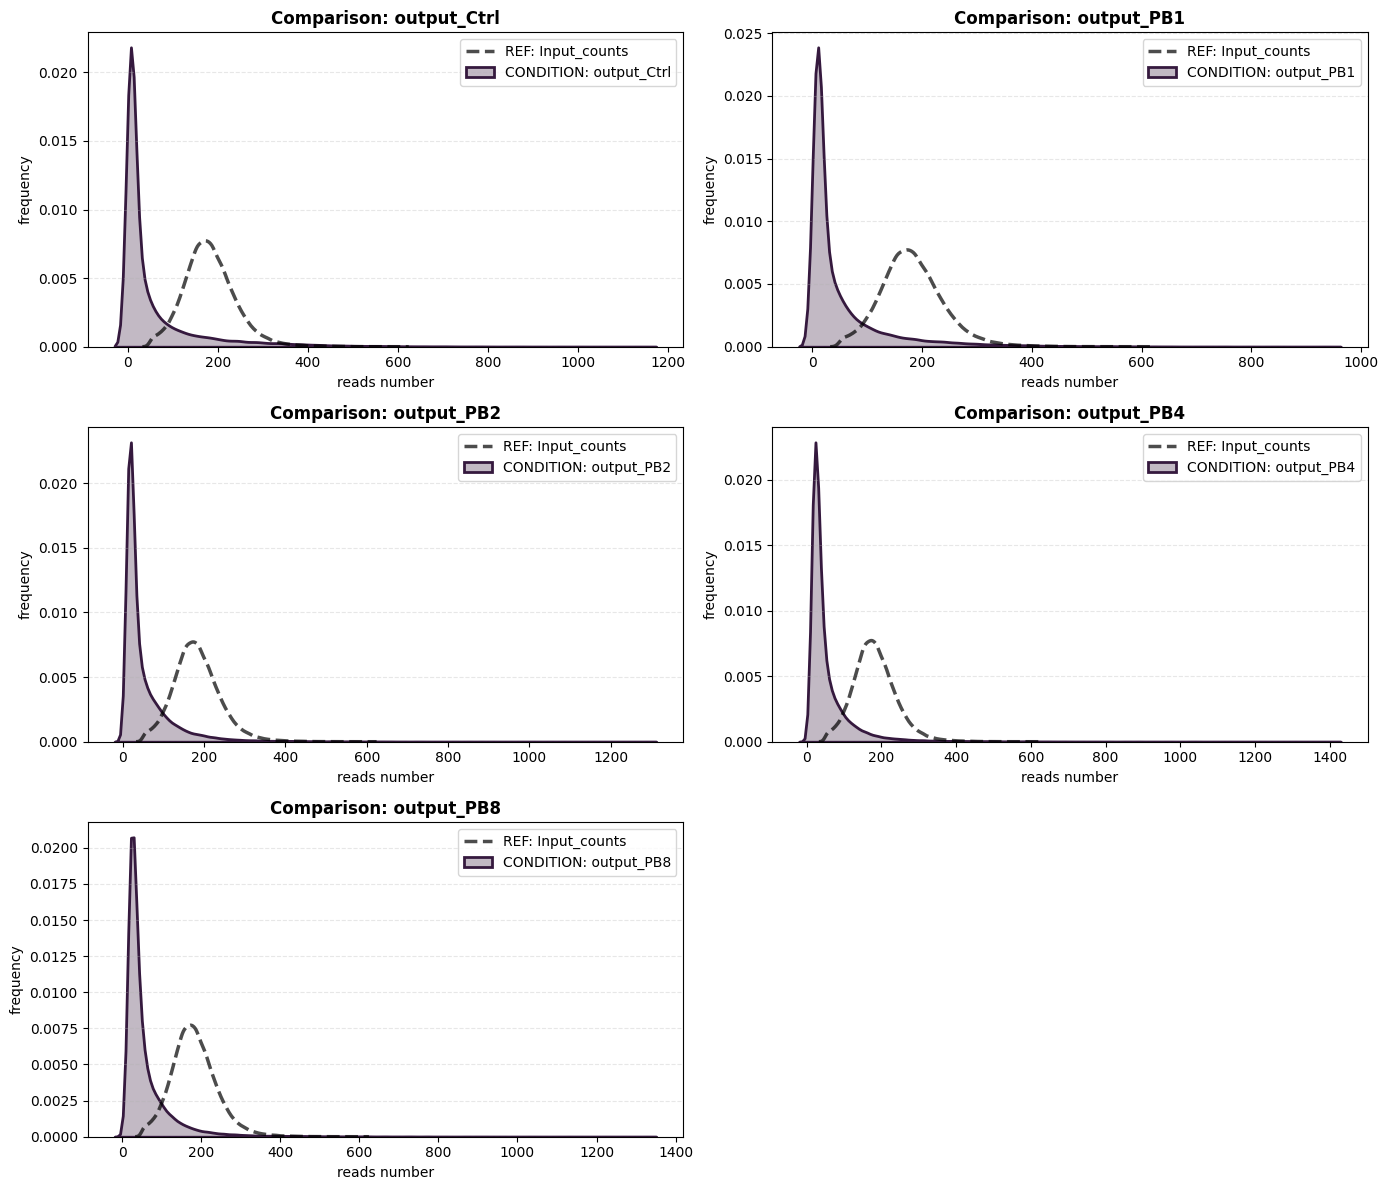

['output_Ctrl', 'output_PB1', 'output_PB2', 'output_PB4', 'output_PB8']


In [11]:
df = data_filtered.copy()

# 1. Filtro colonne (già definito nel tuo script)
df = df[[col for col in df.columns if 'H' not in col]]

# 2. Preparazione liste colonne
input_col = 'Input_counts'
output_list = [col for col in df.columns if 'output' in col]

# 3. Configurazione della griglia di grafici
# Calcoliamo quante righe servono per avere ad esempio 2 colonne di grafici
n_cols = 2
n_rows = math.ceil(len(output_list) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten() # Trasforma la matrice di assi in una lista piatta

# Loop per ogni condizione di output
for i, col in enumerate(output_list):
    ax = axes[i]
    
    # Plot dell'INPUT (sempre presente come riferimento in nero)
    sns.kdeplot(df[input_col], 
                ax=ax,
                fill=False, 
                color="#000000", 
                label=f"REF: {input_col}", 
                alpha=0.7, 
                linewidth=2.5,
                linestyle='--')
    
    # Plot della condizione specifica (OUTPUT)
    sns.kdeplot(df[col], 
                ax=ax,
                fill=True, 
                color=sns.color_palette("rocket")[0], # Colore fisso o variabile
                label=f"CONDITION: {col}", 
                alpha=0.3, 
                linewidth=2)

    # Formattazione del singolo subplot
    ax.set_title(f"Comparison: {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel("reads number")
    ax.set_ylabel("frequency")
    ax.legend(loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

# Rimuoviamo eventuali grafici vuoti se n_rows * n_cols > len(output_list)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print(output_list)

## Visualization of reads distribuction over drug: Before and After Normalization

### Before normalization

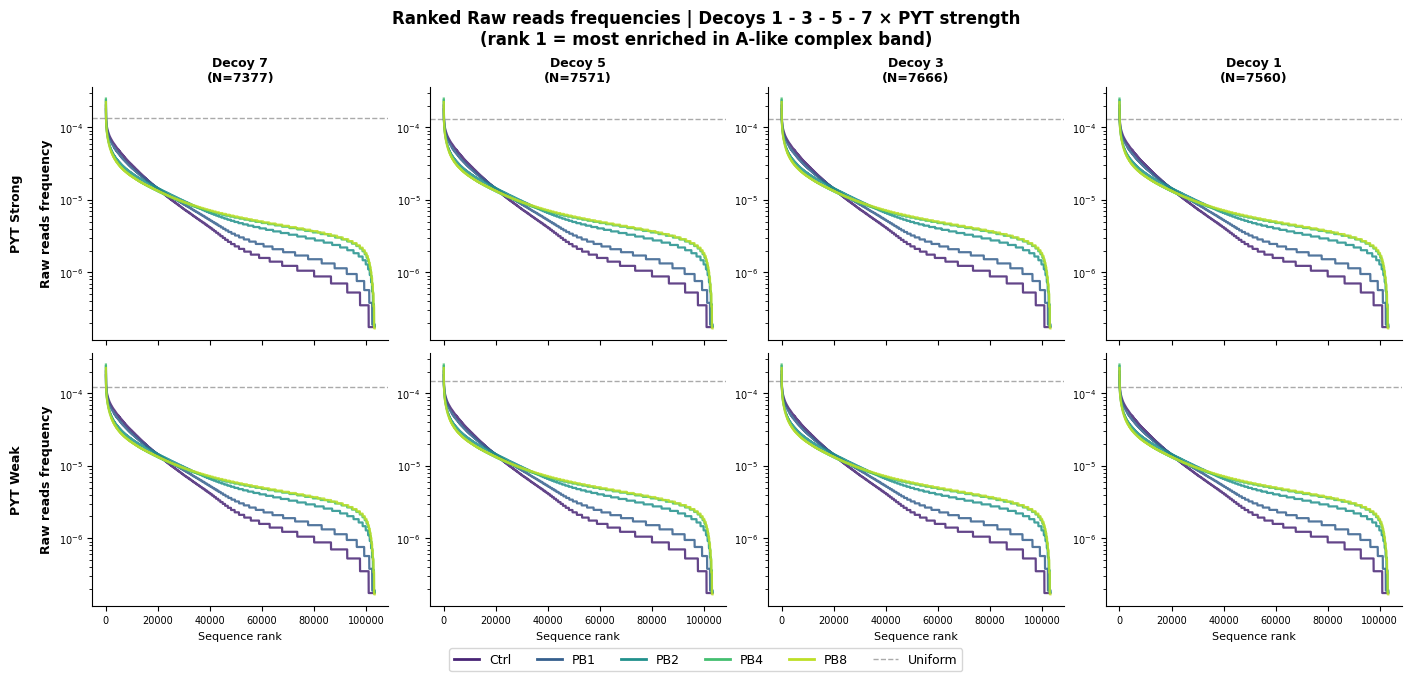

In [12]:
        # Before normalization

# ── 1. Definizione target ──
target_decoys = [f'Decoy {i}' for i in range(7, 0, -2)]
conditions    = ['output_Ctrl', 'output_PB1', 'output_PB2', 'output_PB4', 'output_PB8']
cond_labels   = ['Ctrl', 'PB1', 'PB2', 'PB4', 'PB8']

# ── 2. Struttura griglia ──
pyt_levels = ['Strong', 'Weak']  # righe
n_rows = len(pyt_levels)
n_cols = len(target_decoys)

# ── 3. Palette dose (Viridis) ──
palette = cm.viridis(np.linspace(0.1, 0.9, len(conditions)))

# ── 4. Griglia ──
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 3.5, n_rows * 3.2),
    constrained_layout=True
)

if n_rows == 1: axes = axes[np.newaxis, :]
if n_cols == 1: axes = axes[:, np.newaxis]

for r, pyt in enumerate(pyt_levels):
    for c, decoy in enumerate(target_decoys):
        ax = axes[r, c]
        
        # Recuperiamo i dataframe specifici per questa combinazione
        matching_dfs = [
            stratified_data[k] for k in stratified_data.keys()
            if k[1] == decoy and k[2] == pyt
        ]
        
        if not matching_dfs:
            ax.set_visible(False)
            continue
            
        # Uniamo i dataframe pulendo l'indice per evitare accumuli strani
        df = pd.concat(matching_dfs, axis=0)
        
        # ── TRICK DI SICUREZZA ──
        # Ci assicuriamo di prendere SOLO le righe che appartengono a questo split,
        # estraendo la colonna target ed eliminando eventuali NaN specifici di queste righe
        n_seqs = len(df)

        # ── Plot delle curve rank-abundance sulle CONTE GREZZE ──
        for color, col, label in zip(palette, conditions, cond_labels):
            # Prendiamo i valori grezzi associati a QUESTE specifiche righe filtrate
            vals = data_raw[col].dropna().values
            
            if len(vals) == 0 or vals.sum() == 0:
                continue
            
            # Ordiniamo in modo decrescente
            vals_sorted = np.sort(vals)[::-1]
            ranks = np.arange(1, len(vals_sorted) + 1)

            # Calcoliamo la frequenza relativa locale sul totale di questo sottoinsieme
            rel_freq = vals_sorted / vals.sum()

            ax.plot(ranks, rel_freq, color=color, lw=1.6,
                    alpha=0.85, label=label)

        # Linea uniformità teorica basata sul numero VERO di sequenze dello split
        ax.axhline(1 / n_seqs, color='#aaaaaa', lw=1,
                   linestyle='--', zorder=0)

        ax.set_yscale('log')
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=7)

        # Titolo colonna (mostra anche il numero di sequenze per controllo visivo)
        if r == 0:
            ax.set_title(f'{decoy}\n(N={n_seqs})', fontsize=9, fontweight='bold', pad=4)

        # Etichetta riga
        if c == 0:
            ax.set_ylabel(f'PYT {pyt}\n\nRaw reads frequency',
                          fontsize=9, fontweight='bold')

        # Asse X
        if r == n_rows - 1:
            ax.set_xlabel('Sequence rank', fontsize=8)
        else:
            ax.set_xticklabels([])

# ── 5. Legenda unica in basso ──
handles = [
    plt.Line2D([0], [0], color=palette[i], lw=2, label=cond_labels[i])
    for i in range(len(conditions))
]
handles.append(
    plt.Line2D([0], [0], color='#aaaaaa', lw=1, linestyle='--', label='Uniform')
)
fig.legend(
    handles=handles,
    loc='lower center',
    ncol=len(conditions) + 1,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.05),
    framealpha=0.8
)

fig.suptitle(
    'Ranked Raw reads frequencies | Decoys 1 - 3 - 5 - 7 × PYT strength\n'
    '(rank 1 = most enriched in A-like complex band)',
    fontsize=12, fontweight='bold'
)

plt.show()

### After normalization

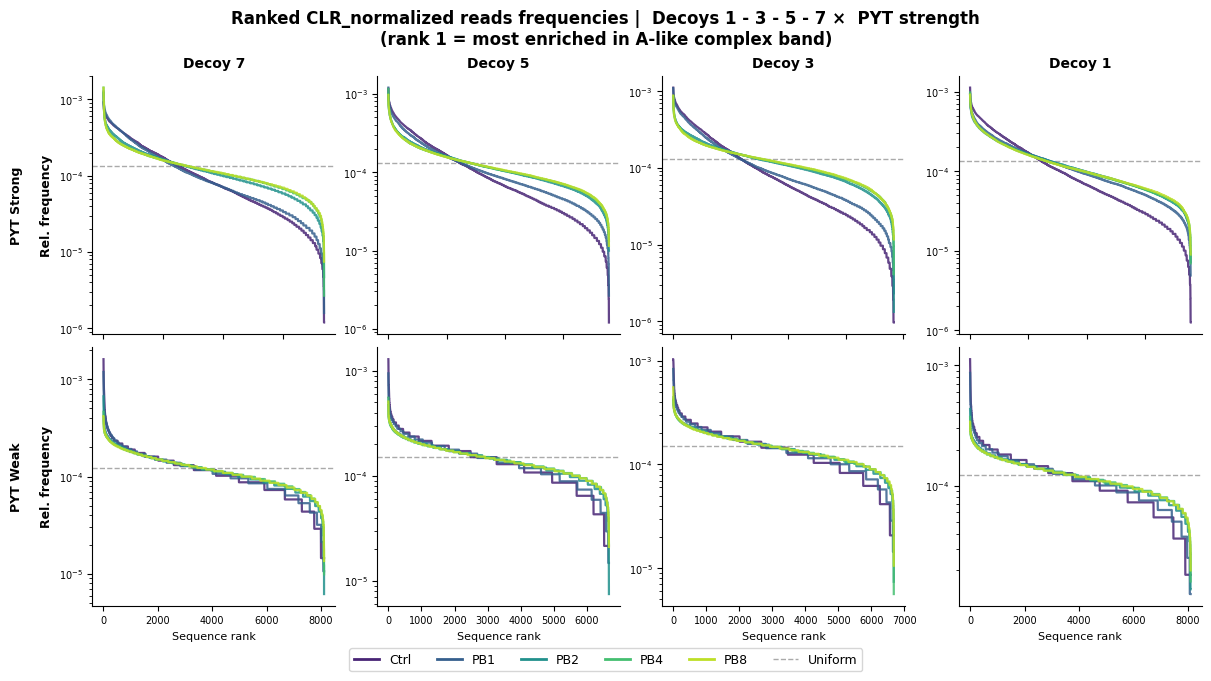

In [13]:


# ── 1. Definizione target (Tutti i Decoy da 1 a 7) ──
target_decoys = [f'Decoy {i}' for i in range(7, 0, -2)]
conditions    = [*normalized]
cond_labels   = ['Ctrl', 'PB1', 'PB2', 'PB4', 'PB8']

# ── 2. Struttura griglia (7 colonne basate solo sui Decoy) ──
pyt_levels = ['Strong', 'Weak']  # righe
n_rows = len(pyt_levels)
n_cols = len(target_decoys)

# ── 3. Palette dose (Viridis) ──
palette = cm.viridis(np.linspace(0.1, 0.9, len(conditions)))

# ── 4. Griglia ──
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 3.0, n_rows * 3.2),  # Adattato leggermente la larghezza per 7 colonne
    constrained_layout=True
)

# Garantisce sempre array 2D
if n_rows == 1: axes = axes[np.newaxis, :]
if n_cols == 1: axes = axes[:, np.newaxis]

for r, pyt in enumerate(pyt_levels):
    for c, decoy in enumerate(target_decoys):
        ax = axes[r, c]
        
        # ── COLLASSAMENTO ANCHOR ──
        # Recuperiamo e uniamo tutti i dataframe di qualsiasi Anchor per questo specifico Decoy e PYT
        matching_dfs = [
            stratified_data[k] for k in stratified_data.keys()
            if k[1] == decoy and k[2] == pyt
        ]
        
        # Se non ci sono dati per questa combinazione, nascondi il subplot
        if not matching_dfs:
            ax.set_visible(False)
            continue
            
        # Concateniamo i dati per collassare l'Anchor
        df = pd.concat(matching_dfs, axis=0).copy()
        n_seqs = len(df)

        # ── Plot delle curve rank-abundance ──
        for color, col, label in zip(palette, conditions, cond_labels):
            vals = df[col].dropna().values
            if len(vals) == 0:
                continue
            
            vals_sorted = np.sort(vals)[::-1]
            ranks = np.arange(1, len(vals_sorted) + 1)

            # exp(LFC) → frequenza relativa
            abundances = np.exp(vals_sorted)
            rel_freq   = abundances / abundances.sum()

            ax.plot(ranks, rel_freq, color=color, lw=1.6,
                    alpha=0.85, label=label)

        # Linea uniformità
        ax.axhline(1 / n_seqs, color='#aaaaaa', lw=1,
                   linestyle='--', zorder=0)

        ax.set_yscale('log')
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=7)

        # Titolo colonna (solo prima riga: mostra solo il Decoy, Anchor è collassato)
        if r == 0:
            ax.set_title(f'{decoy}', fontsize=10, fontweight='bold', pad=6)

        # Etichetta riga (solo prima colonna)
        if c == 0:
            ax.set_ylabel(f'PYT {pyt}\n\nRel. frequency',
                          fontsize=9, fontweight='bold')

        # Asse X (solo ultima riga)
        if r == n_rows - 1:
            ax.set_xlabel('Sequence rank', fontsize=8)
        else:
            ax.set_xticklabels([])

# ── 5. Legenda unica in basso ──
handles = [
    plt.Line2D([0], [0], color=palette[i], lw=2, label=cond_labels[i])
    for i in range(len(conditions))
]
handles.append(
    plt.Line2D([0], [0], color='#aaaaaa', lw=1,
               linestyle='--', label='Uniform')
)
fig.legend(
    handles=handles,
    loc='lower center',
    ncol=len(conditions) + 1,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.05),
    framealpha=0.8
)

fig.suptitle(
    'Ranked CLR_normalized reads frequencies |  Decoys 1 - 3 - 5 - 7 ×  PYT strength\n'
    '(rank 1 = most enriched in A-like complex band)',
    fontsize=12, fontweight='bold'
)

# plt.savefig('rank_abundance_collapsed_grid.pdf', bbox_inches='tight', dpi=150)
plt.show()